# Taller 1 — Fundamentos de Python y primeros pasos en redes

**ECON 64597 · Modelos de Interacciones Sociales · 2026-2**
Prof. Alvaro J. Riascos Villegas — Prof. complementaria: Gabriela Zamora

**Semana de entrega:** 33 · **Peso:** 10% de la nota final · **Grupos:** 2 a 3 personas

---

## Objetivo

Al terminar este taller usted debe ser capaz de: (i) escribir funciones en Python usando
listas, diccionarios, ciclos y comprensiones; (ii) representar un grafo como lista de aristas,
lista de adyacencia y matriz de adyacencia, y moverse entre las tres representaciones;
(iii) calcular con NumPy y con `networkx` las estadisticas descriptivas basicas de una red
(grados, densidad, componentes, distancias, clustering, centralidades); (iv) medir homofilia
y contrastarla contra un modelo nulo aleatorio; y (v) interpretar economicamente los resultados.

Referencias: [J] caps. 1-3 · [EK] caps. 1-4.

## Como trabajar este cuaderno

1. Complete **todas** las celdas marcadas con `# TODO`. No borre las celdas de verificacion
   (`check(...)`): son su autodiagnostico, pero **no** son la calificacion.
2. Responda las preguntas de interpretacion en las celdas de texto indicadas. Se evaluan.
3. El cuaderno debe correr **de principio a fin** con *Kernel > Restart & Run All* sin errores
   y sin conexion a internet.
4. Entregue un `.zip` autocontenido segun las instrucciones del `README_Taller1.md`.

---

### Identificacion del grupo

| | Nombre completo | Codigo | Correo |
|---|---|---|---|
| 1 | | | |
| 2 | | | |
| 3 | | | |

### Declaracion de Uso de IA (obligatoria, seccion 9 del programa)

El uso de IA esta **permitido** en este taller. Complete honestamente:

- **Herramientas usadas:** _(p. ej. Claude, ChatGPT, Copilot, ninguna)_
- **En que puntos la usaron:** _(p. ej. E2.3 y depuracion de la Seccion 4)_
- **Que verificaron ustedes mismos:** _(p. ej. contrastamos el resultado de `nx.diameter` contra nuestro BFS)_
- **Que aprendieron / que corrigieron del output de la IA:**

> Recuerde: en la microreunion se le pedira explicar, modificar y defender cualquier linea de
> este cuaderno. "No se, lo escribio la IA" cuenta como entrega incompleta.

### Declaracion de Uso de IA — version de referencia (solucionario)

Este cuaderno es la **solucion de referencia del equipo docente**. Los estudiantes deben
diligenciar la tabla de integrantes y la Declaracion de Uso de IA arriba; su ausencia
implica entrega incompleta.

---
## 0. Preparacion del entorno

Esta celda importa todo lo que necesitara y define `check`, una funcion auxiliar de
verificacion. **Ejecutela primero.** Si alguna libreria falta, instalela en su entorno
(`pip install -r requirements.txt`) antes de continuar.

In [1]:
import sys
from collections import deque

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # semilla fija: resultados reproducibles

print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("networkx    ", nx.__version__)
print("matplotlib  ", matplotlib.__version__)


def check(nombre, condicion, ayuda=""):
    # Verificacion ligera: NO es la nota, es su autodiagnostico.
    if condicion:
        print("  OK      -", nombre)
    else:
        print("  REVISAR -", nombre, ("| " + ayuda) if ayuda else "")

Python       3.14.6
numpy        2.4.6
pandas       3.0.3
networkx     3.6.1
matplotlib   3.11.0


---
# Seccion 1 — Fundamentos de Python con sabor a redes  *(peso sugerido: 20%)*

Un grafo no dirigido y sin pesos se puede guardar de varias formas. La mas economica es la
**lista de aristas**: una lista de parejas. Trabajaremos primero con una red juguete de 8
nodos para tener control total sobre lo que pasa.

In [2]:
ARISTAS = [("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"),
           ("D", "E"), ("E", "F"), ("F", "D"), ("G", "H")]

print("Numero de aristas:", len(ARISTAS))
ARISTAS

Numero de aristas: 8


[('A', 'B'),
 ('A', 'C'),
 ('B', 'C'),
 ('C', 'D'),
 ('D', 'E'),
 ('E', 'F'),
 ('F', 'D'),
 ('G', 'H')]

### E1.1 — Conjunto de nodos

Escriba `nodos(aristas)` que devuelva la **lista ordenada alfabeticamente y sin repeticiones**
de los nodos que aparecen en una lista de aristas.

*Pista:* un `set` elimina duplicados y `sorted` ordena. Se puede hacer en una sola linea con
una comprension de conjunto.

In [3]:
def nodos(aristas):
    return sorted({n for arista in aristas for n in arista})


N = nodos(ARISTAS)
print(N)
check("E1.1 nodos", N == list("ABCDEFGH"), "deben ser 8 nodos ordenados de la A a la H")

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
  OK      - E1.1 nodos


### E1.2 — Lista de adyacencia

Escriba `lista_adyacencia(aristas)` que devuelva un **diccionario** `{nodo: set(vecinos)}`.
Todo nodo debe aparecer como llave, incluso si tuviera grado 0. Recuerde que el grafo es **no
dirigido**: si `(u, v)` es una arista, `u` es vecino de `v` **y** `v` es vecino de `u`.

In [4]:
def lista_adyacencia(aristas):
    adj = {n: set() for n in nodos(aristas)}
    for u, v in aristas:
        adj[u].add(v)
        adj[v].add(u)
    return adj


ADJ = lista_adyacencia(ARISTAS)
for n in nodos(ARISTAS):
    print(n, "->", sorted(ADJ[n]))

check("E1.2 llaves", set(ADJ) == set(N))
check("E1.2 simetria", all(u in ADJ[v] for u in ADJ for v in ADJ[u]),
      "si v es vecino de u, u debe ser vecino de v")

A -> ['B', 'C']
B -> ['A', 'C']
C -> ['A', 'B', 'D']
D -> ['C', 'E', 'F']
E -> ['D', 'F']
F -> ['D', 'E']
G -> ['H']
H -> ['G']
  OK      - E1.2 llaves
  OK      - E1.2 simetria


### E1.3 — Grados y el lema del apreton de manos

Escriba `grados(adj)` que devuelva `{nodo: grado}` usando una **comprension de diccionario**
(una sola linea dentro de la funcion).

Luego verifique el *handshaking lemma*: la suma de los grados es igual a dos veces el numero
de aristas. Explique en una linea por que.

In [5]:
def grados(adj):
    return {n: len(vecinos) for n, vecinos in adj.items()}


G_grados = grados(ADJ)
print(G_grados)
print("Suma de grados:", sum(G_grados.values()), "| 2 * m =", 2 * len(ARISTAS))

check("E1.3 handshaking", sum(G_grados.values()) == 2 * len(ARISTAS))

{'A': 2, 'B': 2, 'C': 3, 'D': 3, 'E': 2, 'F': 2, 'G': 1, 'H': 1}
Suma de grados: 16 | 2 * m = 16
  OK      - E1.3 handshaking


**Por que se cumple el lema:** cada arista contribuye exactamente 1 al grado de cada uno
de sus dos extremos, es decir 2 en total a la suma de grados. Como consecuencia inmediata, el
numero de nodos de grado impar siempre es par.

### E1.4 — Similaridad de Jaccard

Dos nodos se parecen si comparten vecinos. El **coeficiente de Jaccard** entre `u` y `v` es

$$J(u,v) = \frac{|\Gamma(u) \cap \Gamma(v)|}{|\Gamma(u) \cup \Gamma(v)|}$$

donde $\Gamma(x)$ es el conjunto de vecinos de $x$. Implementelo (devuelva `0.0` si la union
es vacia) y calculelo para los pares `(A, B)`, `(A, D)` y `(A, G)`.

In [6]:
def jaccard(adj, u, v):
    interseccion = adj[u] & adj[v]
    union = adj[u] | adj[v]
    return len(interseccion) / len(union) if union else 0.0


for u, v in [("A", "B"), ("A", "D"), ("A", "G")]:
    print("J(%s,%s) = %.3f" % (u, v, jaccard(ADJ, u, v)))

check("E1.4 J(A,B)", abs(jaccard(ADJ, "A", "B") - 1 / 3) < 1e-9)
check("E1.4 J(A,G)", jaccard(ADJ, "A", "G") == 0.0)

J(A,B) = 0.333
J(A,D) = 0.250
J(A,G) = 0.000
  OK      - E1.4 J(A,B)
  OK      - E1.4 J(A,G)


### E1.5 — BFS: distancias desde un origen

Implemente una busqueda en anchura (*breadth-first search*) que devuelva
`{nodo: distancia}` para todos los nodos **alcanzables** desde `origen`. Los nodos no
alcanzables simplemente no aparecen en el diccionario.

*Pista:* use `deque` como cola. El invariante es: cuando saca `u` de la cola, ya conoce
`dist[u]`; todo vecino no visitado esta a `dist[u] + 1`.

Esta funcion es la que despues comparara contra `networkx` — no la borre.

In [7]:
def bfs_distancias(adj, origen):
    dist = {origen: 0}
    cola = deque([origen])
    while cola:
        u = cola.popleft()
        for v in adj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                cola.append(v)
    return dist


d_A = bfs_distancias(ADJ, "A")
print("Distancias desde A:", d_A)
print("Distancias desde G:", bfs_distancias(ADJ, "G"))

check("E1.5 d(A,A)=0", d_A["A"] == 0)
check("E1.5 d(A,F)=3", d_A.get("F") == 3)
check("E1.5 G no alcanzable desde A", "G" not in d_A,
      "A y G estan en componentes distintas")

Distancias desde A: {'A': 0, 'C': 1, 'B': 1, 'D': 2, 'F': 3, 'E': 3}
Distancias desde G: {'G': 0, 'H': 1}
  OK      - E1.5 d(A,A)=0
  OK      - E1.5 d(A,F)=3
  OK      - E1.5 G no alcanzable desde A


---
# Seccion 2 — NumPy y la matriz de adyacencia  *(peso sugerido: 15%)*

La matriz de adyacencia $A$ de un grafo de $n$ nodos es $n \times n$ con $A_{ij} = 1$ si
$i$ y $j$ son vecinos y $0$ en otro caso. Para grafos no dirigidos $A$ es simetrica y su
diagonal es cero (no hay auto-lazos). Es la representacion que permite hacer **algebra
lineal** con la red.

### E2.1 — De lista de aristas a matriz

Escriba `matriz_adyacencia(aristas)` que devuelva la tupla `(A, orden)`, donde `A` es un
`np.ndarray` de enteros y `orden` es la lista de nodos que define las filas/columnas.

*Pista:* construya primero un diccionario `{nodo: indice}` con `enumerate`.

In [9]:
def matriz_adyacencia(aristas):
    orden = nodos(aristas)
    idx = {n: i for i, n in enumerate(orden)}
    A = np.zeros((len(orden), len(orden)), dtype=int)
    for u, v in aristas:
        A[idx[u], idx[v]] = 1
        A[idx[v], idx[u]] = 1
    return A, orden


A, orden = matriz_adyacencia(ARISTAS)
print(pd.DataFrame(A, index=orden, columns=orden))

check("E2.1 dimension", A.shape == (8, 8))
check("E2.1 simetrica", np.array_equal(A, A.T))
check("E2.1 sin auto-lazos", np.trace(A) == 0)
check("E2.1 numero de unos", A.sum() == 2 * len(ARISTAS))

   A  B  C  D  E  F  G  H
A  0  1  1  0  0  0  0  0
B  1  0  1  0  0  0  0  0
C  1  1  0  1  0  0  0  0
D  0  0  1  0  1  1  0  0
E  0  0  0  1  0  1  0  0
F  0  0  0  1  1  0  0  0
G  0  0  0  0  0  0  0  1
H  0  0  0  0  0  0  1  0
  OK      - E2.1 dimension
  OK      - E2.1 simetrica
  OK      - E2.1 sin auto-lazos
  OK      - E2.1 numero de unos


### E2.2 — Grados por algebra lineal

Obtenga el vector de grados **directamente de `A`** (sin ciclos de Python) y verifique que
coincide con lo que calculo en E1.3. Guardelo en `grados_np`.

In [10]:
grados_np = A.sum(axis=1)

print(dict(zip(orden, grados_np)))
check("E2.2 coincide con E1.3",
      all(grados_np[i] == G_grados[n] for i, n in enumerate(orden)))

{'A': np.int64(2), 'B': np.int64(2), 'C': np.int64(3), 'D': np.int64(3), 'E': np.int64(2), 'F': np.int64(2), 'G': np.int64(1), 'H': np.int64(1)}
  OK      - E2.2 coincide con E1.3


### E2.3 — Potencias de la matriz: contar caminos y triangulos

Un resultado clasico: la entrada $(i,j)$ de $A^k$ cuenta el numero de **recorridos** (walks)
de longitud exactamente $k$ entre $i$ y $j$.

1. Calcule `A2 = A^2` y `A3 = A^3` con `np.linalg.matrix_power`.
2. Cuente cuantos recorridos de longitud 3 hay de `A` a `D`.
3. Calcule el numero de **triangulos** del grafo. Cada triangulo se cuenta 6 veces en
   `trace(A^3)` (3 vertices de partida x 2 sentidos), de modo que el numero de triangulos es
   $\operatorname{tr}(A^3)/6$.

In [11]:
A2 = np.linalg.matrix_power(A, 2)
A3 = np.linalg.matrix_power(A, 3)

i_A, i_D = orden.index("A"), orden.index("D")
caminos_AD_3 = A3[i_A, i_D]
n_triangulos = int(np.trace(A3) // 6)

print("Recorridos de longitud 3 entre A y D:", caminos_AD_3)
print("Numero de triangulos:", n_triangulos)

check("E2.3 triangulos", n_triangulos == 2, "ABC y DEF")
check("E2.3 diagonal de A2 = grados", np.array_equal(np.diag(A2), grados_np),
      "un recorrido de longitud 2 de i a i es ir a un vecino y volver")

Recorridos de longitud 3 entre A y D: 1
Numero de triangulos: 2
  OK      - E2.3 triangulos
  OK      - E2.3 diagonal de A2 = grados


**Pregunta:** la diagonal de $A^2$ resulta ser exactamente el vector de grados. Explique
por que en terminos de recorridos.

**Respuesta:** un recorrido de longitud 2 que empieza y termina en $i$ consiste en ir a un
vecino y devolverse. Hay tantos como vecinos tenga $i$, es decir $\deg(i)$. Note que un
*recorrido* puede repetir nodos y aristas; por eso no es un *camino* (path) en sentido
estricto.

### E2.4 — Densidad

La densidad de un grafo no dirigido simple es la fraccion de las aristas posibles que
efectivamente existen: $d = \dfrac{2m}{n(n-1)}$. Calculela **a partir de `A`**.

In [12]:
n = A.shape[0]
m = int(A.sum() // 2)
densidad = 2 * m / (n * (n - 1))

print("n = %d, m = %d, densidad = %.4f" % (n, m, densidad))
check("E2.4 densidad", abs(densidad - 8 / 28) < 1e-9)

n = 8, m = 8, densidad = 0.2857
  OK      - E2.4 densidad


---
# Seccion 3 — Pandas: cargar y explorar datos de red  *(peso sugerido: 20%)*

Pasamos a una red real y clasica: el **club de karate de Zachary** (34 miembros de un club
universitario; una arista indica interaccion social por fuera del club). El club se dividio en
dos tras un conflicto entre el instructor (`Mr. Hi`) y el administrador (`Officer`), y el
atributo `club` registra a que faccion quedo cada miembro.

La celda siguiente **genera los archivos CSV localmente** (no requiere internet). Ejecutela
tal cual.

In [13]:
G_karate = nx.karate_club_graph()

df_aristas = pd.DataFrame(list(G_karate.edges()), columns=["source", "target"])
df_nodos = pd.DataFrame({
    "nodo": list(G_karate.nodes()),
    "club": [G_karate.nodes[i]["club"] for i in G_karate.nodes()],
})

df_aristas.to_csv("red_aristas.csv", index=False)
df_nodos.to_csv("red_nodos.csv", index=False)
print("Archivos escritos: red_aristas.csv, red_nodos.csv")

Archivos escritos: red_aristas.csv, red_nodos.csv


### E3.1 — Cargar los datos

Lea los dos CSV con `pd.read_csv` en `aristas` y `atributos`. Imprima la forma de cada uno y
las primeras filas. **Nunca** trabaje con datos que no haya mirado antes.

In [14]:
aristas = pd.read_csv("red_aristas.csv")
atributos = pd.read_csv("red_nodos.csv")

print("aristas:", aristas.shape, "| atributos:", atributos.shape)
display(aristas.head())
display(atributos.head())

check("E3.1 aristas", aristas.shape == (78, 2))
check("E3.1 atributos", atributos.shape == (34, 2))

aristas: (78, 2) | atributos: (34, 2)


,source,target
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


,nodo,club
0,0,Mr. Hi
1,1,Mr. Hi
2,2,Mr. Hi
3,3,Mr. Hi
4,4,Mr. Hi


  OK      - E3.1 aristas
  OK      - E3.1 atributos


### E3.2 — Grados con pandas

Sin usar `networkx`, construya `df_grados`: un DataFrame con columnas `nodo` y `grado`,
ordenado de mayor a menor grado. Muestre los 5 nodos mas conectados.

*Pista:* apile las dos columnas de `aristas` con `pd.concat` y use `value_counts`.

In [15]:
df_grados = (pd.concat([aristas["source"], aristas["target"]])
               .value_counts()
               .rename_axis("nodo")
               .reset_index(name="grado")
               .sort_values("grado", ascending=False)
               .reset_index(drop=True))

display(df_grados.head())

check("E3.2 filas", len(df_grados) == 34)
check("E3.2 suma de grados", df_grados["grado"].sum() == 2 * len(aristas))
check("E3.2 nodo mas conectado", df_grados.loc[0, "nodo"] == 33)

,nodo,grado
0,33,17
1,0,16
2,32,12
3,2,10
4,1,9


  OK      - E3.2 filas
  OK      - E3.2 suma de grados
  OK      - E3.2 nodo mas conectado


### E3.3 — Cruce con atributos y estadisticas por grupo

1. Una `df_grados` con `atributos` (`merge` sobre `nodo`) en `df`.
2. Calcule, por faccion (`club`): numero de miembros, grado promedio, grado mediano y grado maximo.
3. Comente en una linea que sugiere la comparacion.

In [16]:
df = df_grados.merge(atributos, on="nodo", how="left")

resumen = (df.groupby("club")["grado"]
             .agg(miembros="size", promedio="mean", mediana="median", maximo="max")
             .round(2))
display(resumen)

check("E3.3 sin faltantes", df["club"].notna().all())
check("E3.3 dos facciones", len(resumen) == 2)

,miembros,promedio,mediana,maximo
club,,,,
Mr. Hi,17,4.76,4.0,16
Officer,17,4.41,3.0,17


  OK      - E3.3 sin faltantes
  OK      - E3.3 dos facciones


**Comentario:** las dos facciones son de tamano parecido, pero la distribucion de grados
es muy desigual **dentro** de cada una: en ambas hay un lider con grado muy alto (los nodos 0
y 33) rodeado de miembros de grado bajo. Es decir, la red no es homogenea sino centrada en
lideres, lo que anticipa el estudio de centralidad y de leyes de potencia mas adelante en el curso.

### E3.4 — Primera medida de homofilia

Una arista es **cruzada** si conecta miembros de facciones distintas. Calcule la fraccion de
aristas cruzadas usando solo pandas (`merge` de los atributos sobre `source` y sobre `target`).

In [17]:
ar = (aristas
      .merge(atributos.rename(columns={"nodo": "source", "club": "club_s"}), on="source")
      .merge(atributos.rename(columns={"nodo": "target", "club": "club_t"}), on="target"))

ar["cruzada"] = ar["club_s"] != ar["club_t"]
frac_cruzadas = ar["cruzada"].mean()

print("Aristas cruzadas: %d de %d (%.3f)" % (ar["cruzada"].sum(), len(ar), frac_cruzadas))
check("E3.4 fraccion", 0 < frac_cruzadas < 0.5)

Aristas cruzadas: 11 de 78 (0.141)
  OK      - E3.4 fraccion


---
# Seccion 4 — NetworkX: estadisticas descriptivas de la red  *(peso sugerido: 30%)*

Ahora si usamos la libreria estandar. Regla del curso: **primero entender, despues delegar**.
En varios puntos se le pide contrastar el resultado de `networkx` contra el codigo que usted
escribio en la Seccion 1.

### E4.1 — Construir el grafo

Construya `G` desde `aristas` con `nx.from_pandas_edgelist` y agregue el atributo `club` a
cada nodo con `nx.set_node_attributes`. Reporte $n$, $m$ y la densidad.

In [18]:
G = nx.from_pandas_edgelist(aristas, source="source", target="target")
nx.set_node_attributes(G, atributos.set_index("nodo")["club"].to_dict(), name="club")

print("n =", G.number_of_nodes())
print("m =", G.number_of_edges())
print("densidad = %.4f" % nx.density(G))

check("E4.1 n", G.number_of_nodes() == 34)
check("E4.1 m", G.number_of_edges() == 78)
check("E4.1 atributo club", all("club" in G.nodes[i] for i in G.nodes))

n = 34
m = 78
densidad = 0.1390
  OK      - E4.1 n
  OK      - E4.1 m
  OK      - E4.1 atributo club


### E4.2 — Distribucion de grados

Grafique la distribucion de grados en dos paneles: (a) histograma en escala lineal;
(b) distribucion complementaria acumulada $P(K \ge k)$ en escala log-log.

Los ejes deben ir rotulados y cada panel debe tener titulo. La escala log-log es el
diagnostico visual estandar para leyes de potencia (tema de la Semana 37).

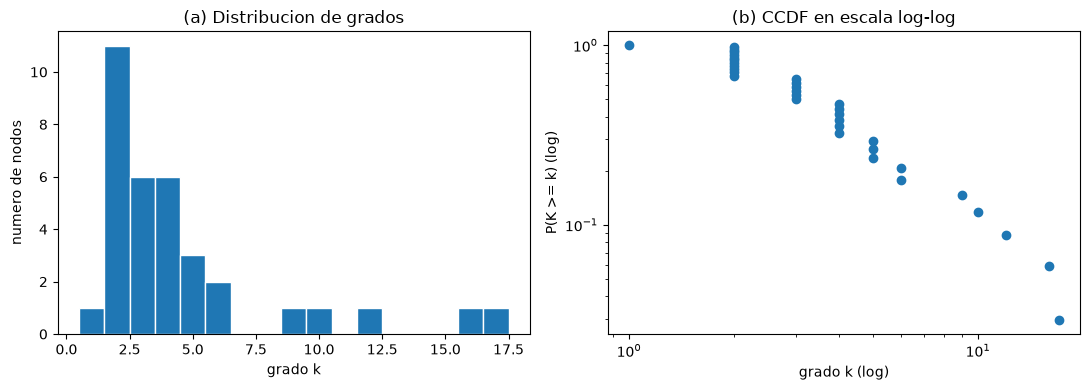

grado medio = 4.59 | mediana = 3.0 | maximo = 17


In [19]:
grados_lista = np.array([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(grados_lista, bins=range(1, grados_lista.max() + 2), align="left",
             edgecolor="white")
axes[0].set_xlabel("grado k")
axes[0].set_ylabel("numero de nodos")
axes[0].set_title("(a) Distribucion de grados")

ks = np.sort(grados_lista)
ccdf = 1.0 - np.arange(len(ks)) / len(ks)
axes[1].loglog(ks, ccdf, marker="o", linestyle="none")
axes[1].set_xlabel("grado k (log)")
axes[1].set_ylabel("P(K >= k) (log)")
axes[1].set_title("(b) CCDF en escala log-log")

plt.tight_layout()
plt.show()

print("grado medio = %.2f | mediana = %.1f | maximo = %d"
      % (grados_lista.mean(), np.median(grados_lista), grados_lista.max()))

### E4.3 — Conectividad y componentes

Reporte si `G` es conexo, cuantas componentes conexas tiene y el tamano de la componente
gigante. Guarde en `Gc` el subgrafo inducido por la componente gigante (usela de aqui en
adelante para distancias).

In [20]:
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
print("conexo:", nx.is_connected(G))
print("numero de componentes:", len(componentes))
print("tamanos:", [len(c) for c in componentes])

Gc = G.subgraph(componentes[0]).copy()
print("componente gigante:", Gc.number_of_nodes(), "nodos")

check("E4.3 componente gigante", Gc.number_of_nodes() == 34,
      "esta red particular es conexa")

conexo: True
numero de componentes: 1
tamanos: [34]
componente gigante: 34 nodos
  OK      - E4.3 componente gigante


### E4.4 — Distancias: su BFS contra networkx

1. Construya la lista de adyacencia de `Gc` como diccionario `{nodo: set(vecinos)}` y calcule
   con **su** `bfs_distancias` (E1.5) las distancias desde el nodo 0.
2. Comparelas con `nx.single_source_shortest_path_length(Gc, 0)`. Deben ser identicas.
3. Reporte la distancia promedio y el diametro de `Gc`.

In [21]:
adj_gc = {u: set(Gc.neighbors(u)) for u in Gc.nodes()}

d_mio = bfs_distancias(adj_gc, 0)
d_nx = dict(nx.single_source_shortest_path_length(Gc, 0))

check("E4.4 mi BFS coincide con networkx", d_mio == d_nx)

dist_prom = nx.average_shortest_path_length(Gc)
diametro = nx.diameter(Gc)
print("distancia promedio = %.3f" % dist_prom)
print("diametro = %d" % diametro)

check("E4.4 diametro", diametro == 5)

  OK      - E4.4 mi BFS coincide con networkx
distancia promedio = 2.408
diametro = 5
  OK      - E4.4 diametro


### E4.5 — Clustering

Calcule el coeficiente de clustering **promedio** (`nx.average_clustering`) y el clustering
**global** o transitividad (`nx.transitivity`), e identifique los 3 nodos con mayor y los 3 con
menor clustering local (entre los que tengan grado $\ge 2$).

Recuerde: el clustering local de $i$ es la fraccion de pares de vecinos de $i$ que estan
conectados entre si. Es la formalizacion de "los amigos de mis amigos son mis amigos"
([EK] cap. 3).

In [22]:
c_prom = nx.average_clustering(G)
c_global = nx.transitivity(G)
print("clustering promedio = %.4f" % c_prom)
print("transitividad (global) = %.4f" % c_global)

cl = pd.Series(nx.clustering(G))
grados_serie = pd.Series(dict(G.degree()))
cl_validos = cl[grados_serie >= 2].sort_values(ascending=False)

print("\nMayor clustering local:")
print(cl_validos.head(3).round(3))
print("\nMenor clustering local:")
print(cl_validos.tail(3).round(3))

clustering promedio = 0.5706
transitividad (global) = 0.2557

Mayor clustering local:
7     1.0
22    1.0
21    1.0
dtype: float64

Menor clustering local:
0     0.15
33    0.11
9     0.00
dtype: float64


### E4.6 — Centralidades

Construya `df_cent`, un DataFrame indexado por nodo con cuatro columnas: `grado`
(centralidad de grado normalizada), `cercania` (closeness), `intermediacion` (betweenness) y
`eigenvector`. Muestre el top-5 segun intermediacion.

Luego calcule la correlacion de **Spearman** entre las cuatro medidas.

In [23]:
df_cent = pd.DataFrame({
    "grado": nx.degree_centrality(G),
    "cercania": nx.closeness_centrality(G),
    "intermediacion": nx.betweenness_centrality(G),
    "eigenvector": nx.eigenvector_centrality(G, max_iter=1000),
})

display(df_cent.sort_values("intermediacion", ascending=False).head(5).round(4))
print("\nCorrelacion de Spearman entre centralidades:")
display(df_cent.corr(method="spearman").round(3))

check("E4.6 columnas", list(df_cent.columns) == ["grado", "cercania",
                                                "intermediacion", "eigenvector"])

,grado,cercania,intermediacion,eigenvector
0,0.4848,0.5690,0.4376,0.3555
33,0.5152,0.5500,0.3041,0.3734
32,0.3636,0.5156,0.1452,0.3087
2,0.3030,0.5593,0.1437,0.3172
31,0.1818,0.5410,0.1383,0.1910



Correlacion de Spearman entre centralidades:


,grado,cercania,intermediacion,eigenvector
grado,1.000,0.895,0.905,0.777
cercania,0.895,1.000,0.898,0.856
intermediacion,0.905,0.898,1.000,0.694
eigenvector,0.777,0.856,0.694,1.000


  OK      - E4.6 columnas


**Interpretacion:** las cuatro medidas estan altamente correlacionadas, pero **no** son
intercambiables. El caso interesante es el nodo 0 frente al nodo 33 y, sobre todo, el nodo 2:
tiene grado moderado pero intermediacion alta porque **conecta las dos facciones**. Un nodo
puede tener pocos amigos y aun asi ser indispensable para el flujo de informacion —esa es la
diferencia entre "ser popular" y "estar en el lugar correcto", y es la intuicion detras de los
*lazos debiles* de Granovetter ([EK] cap. 3).

### E4.7 — Visualizacion

Dibuje la red con `nx.spring_layout(G, seed=42)`, coloreando los nodos por faccion y con
tamano proporcional a la centralidad de intermediacion. Incluya titulo y leyenda de colores.

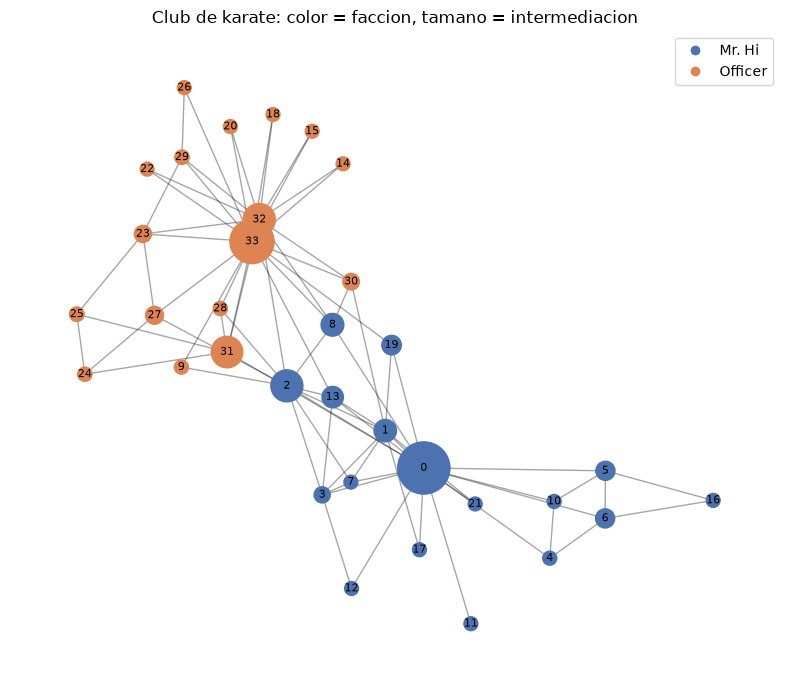

In [24]:
pos = nx.spring_layout(G, seed=42)
es_hi = np.array([G.nodes[i]["club"] == "Mr. Hi" for i in G.nodes()])
colores = np.where(es_hi, "#4C72B0", "#DD8452")
tam = 100 + 3000 * df_cent.loc[list(G.nodes()), "intermediacion"].values

fig, ax = plt.subplots(figsize=(8, 7))
nx.draw_networkx_edges(G, pos, alpha=0.35, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=tam, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Club de karate: color = faccion, tamano = intermediacion")
ax.axis("off")

handles = [plt.Line2D([], [], marker="o", linestyle="none", color="#4C72B0", label="Mr. Hi"),
           plt.Line2D([], [], marker="o", linestyle="none", color="#DD8452", label="Officer")]
ax.legend(handles=handles, loc="best")
plt.tight_layout()
plt.show()

---
# Seccion 5 — Homofilia contra un modelo nulo  *(peso sugerido: 15%)*

En E3.4 usted encontro que pocas aristas cruzan las facciones. Pero **un numero bajo no prueba
nada por si solo**: si un grupo es pequeno, habra pocas aristas cruzadas incluso con
emparejamiento puramente aleatorio. Necesitamos un **modelo nulo**.

Siguiendo [EK] cap. 4: si cada nodo escogiera vecinos al azar, con fracciones poblacionales
$p$ y $q = 1-p$, la probabilidad de que una arista sea cruzada seria $2pq$. La red exhibe
**homofilia** si la fraccion observada de aristas cruzadas es sustancialmente **menor** que $2pq$.

### E5.1 — Test analitico de homofilia

Calcule $p$, $q$, el valor esperado $2pq$ y comparelo con `frac_cruzadas` de E3.4.

In [25]:
p = (atributos["club"] == "Mr. Hi").mean()
q = 1 - p
esperado = 2 * p * q

print("p (Mr. Hi)      = %.4f" % p)
print("q (Officer)     = %.4f" % q)
print("2pq esperado    = %.4f" % esperado)
print("observado       = %.4f" % frac_cruzadas)
print("razon obs/esp   = %.3f" % (frac_cruzadas / esperado))

check("E5.1 hay homofilia", frac_cruzadas < esperado)

p (Mr. Hi)      = 0.5000
q (Officer)     = 0.5000
2pq esperado    = 0.5000
observado       = 0.1410
razon obs/esp   = 0.282
  OK      - E5.1 hay homofilia


### E5.2 — Test por permutaciones (modelo nulo empirico)

El calculo anterior ignora la estructura de grados. Un modelo nulo mas honesto: **mantenga
fija la red** y permute aleatoriamente las etiquetas `club` entre los nodos 5.000 veces,
recalculando cada vez la fraccion de aristas cruzadas. Eso genera la distribucion de la
estadistica bajo la hipotesis nula de "las etiquetas no tienen relacion con la estructura".

1. Escriba la simulacion (use `rng.permutation`).
2. Reporte el p-valor empirico de una cola: la proporcion de permutaciones con fraccion
   cruzada **menor o igual** a la observada.
3. Grafique la distribucion nula con una linea vertical en el valor observado.

observado = 0.1410
media bajo el nulo = 0.5138
p-valor empirico (una cola) = 0.0000


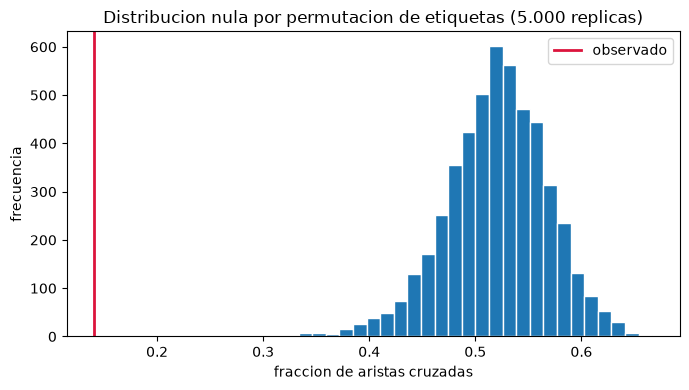

  OK      - E5.2 significativo al 5%


In [26]:
etiquetas = atributos.set_index("nodo")["club"]
src = aristas["source"].values
tgt = aristas["target"].values
lab = etiquetas.loc[sorted(etiquetas.index)].values

n_sim = 5000
simuladas = np.empty(n_sim)
for s in range(n_sim):
    perm = rng.permutation(lab)
    simuladas[s] = (perm[src] != perm[tgt]).mean()

p_valor = (simuladas <= frac_cruzadas).mean()
print("observado = %.4f" % frac_cruzadas)
print("media bajo el nulo = %.4f" % simuladas.mean())
print("p-valor empirico (una cola) = %.4f" % p_valor)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(simuladas, bins=30, edgecolor="white")
ax.axvline(frac_cruzadas, color="crimson", linewidth=2, label="observado")
ax.set_xlabel("fraccion de aristas cruzadas")
ax.set_ylabel("frecuencia")
ax.set_title("Distribucion nula por permutacion de etiquetas (5.000 replicas)")
ax.legend()
plt.tight_layout()
plt.show()

check("E5.2 significativo al 5%", p_valor < 0.05)

### E5.3 — Comparacion con un grafo de Erdos-Renyi

Genere 200 grafos $G(n, p)$ con el mismo $n$ y la misma densidad que `G`, y compare el
clustering promedio y la distancia promedio observados contra la distribucion aleatoria.
Descarte las replicas que resulten no conexas al calcular la distancia promedio.

In [ ]:
n_g = G.number_of_nodes()
p_g = nx.density(G)

cl_sim, d_sim = [], []
for s in range(200):
    H = nx.erdos_renyi_graph(n_g, p_g, seed=int(rng.integers(1e9)))
    cl_sim.append(nx.average_clustering(H))
    if nx.is_connected(H):
        d_sim.append(nx.average_shortest_path_length(H))

print("clustering:  observado = %.4f | aleatorio = %.4f" % (c_prom, np.mean(cl_sim)))
print("distancia:   observado = %.4f | aleatorio = %.4f" % (dist_prom, np.mean(d_sim)))
print("(%d de 200 replicas aleatorias resultaron conexas)" % len(d_sim))

**Lectura del resultado:** el clustering observado es varias veces mayor que el de un
grafo aleatorio de la misma densidad, mientras que la distancia promedio es apenas un poco
mayor. Esa combinacion —**alto clustering + distancias cortas**— es exactamente la firma del
fenomeno de *mundo pequeno*, que un modelo puramente aleatorio no reproduce y que motiva los
modelos de formacion de redes que veremos en las semanas siguientes.

---
# Seccion 6 — Preguntas de interpretacion  *(peso sugerido: 15%)*

Responda en las celdas de texto. Se evalua el **razonamiento economico y estadistico**, no la
extension: dos o tres parrafos bien argumentados valen mas que una pagina. Prepare estas
respuestas para defenderlas oralmente en la microreunion.

**P1.** Suponga que un investigador solo observa la lista de aristas y **no** el atributo
`club`. Con las herramientas de este taller, describa como intentaria detectar que la red
esta dividida en dos grupos. Que evidencia buscaria y cual seria la principal limitacion de
su aproximacion?

**Respuesta guia (equipo docente).** Sin las etiquetas hay varias senales: (i) el
histograma de distancias y la existencia de pocos "puentes" —aristas cuya remocion aumenta
mucho la distancia entre sus extremos; (ii) nodos con intermediacion desproporcionadamente
alta respecto a su grado, que es lo tipico de quien conecta comunidades; (iii) el clustering
local alto dentro de bloques; (iv) el signo del segundo vector propio del laplaciano
(particion espectral) o algoritmos de deteccion de comunidades. La limitacion central es que
la particion detectada es una **hipotesis estructural**, no una identificacion de la variable
que genera la separacion: la estructura es compatible con muchas etiquetas latentes (faccion,
edad, barrio, horario de entrenamiento). Sin datos externos no se puede distinguir homofilia
por seleccion de influencia social, ni identificar la dimension relevante.

**P2.** El test de E5.2 permuta las etiquetas manteniendo fija la red. Que hipotesis
nula esta contrastando exactamente? Por que ese modelo nulo es preferible al calculo
analitico $2pq$ de E5.1?

**Respuesta guia.** La hipotesis nula es que la asignacion de etiquetas es **intercambiable**
entre nodos: las etiquetas no guardan relacion con la posicion de cada nodo en la red. Es
preferible a $2pq$ porque preserva exactamente el numero de nodos, la secuencia de grados y
toda la topologia observada; lo unico que aleatoriza es la etiqueta. El calculo $2pq$ supone
implicitamente emparejamiento uniforme entre todos los pares posibles, un supuesto que la red
real viola de forma evidente (grados muy heterogeneos). Advertencia importante: el test
detecta **asociacion**, no un mecanismo. Rechazar el nulo no dice si la homofilia proviene de
seleccion (la gente escoge similares) o de influencia (los conectados se vuelven similares);
en este caso particular hay ademas causalidad inversa plausible, porque la faccion se definio
**despues** del conflicto y probablemente en funcion de los lazos previos.

**P3.** Los datos del club de karate provienen de la observacion directa de un
antropologo durante dos anos. Compare esa forma de recoleccion con la de una red extraida hoy
de una plataforma digital (p. ej. seguidores en una red social). Mencione al menos dos sesgos
de medicion y una implicacion para la validez de los resultados.

**Respuesta guia.** Diferencias relevantes: (i) *definicion de arista* — el observador
registra interaccion social sostenida fuera del club, mientras que "seguir" es una accion de
costo casi nulo y no implica interaccion; los objetos medidos no son comparables. (ii)
*frontera de la red* — aqui la poblacion esta cerrada y es censal (34 miembros); en una
plataforma la frontera es arbitraria y el muestreo por bola de nieve o por API sobre-representa
nodos centrales. (iii) *sesgo del observador y reactividad* frente a *sesgo de plataforma*: las
aristas digitales estan moldeadas por el algoritmo de recomendacion, de modo que se mide en
parte el producto y no la sociabilidad. (iv) *escala y dinamica*: 78 aristas permiten inspeccion
manual; millones no, y las redes digitales son dinamicas mientras aqui se observa un corte.
Implicacion: los estadisticos descriptivos (clustering, distancias, exponentes de cola) son
sensibles a la definicion de arista y al muestreo, por lo que comparar valores entre estudios
sin homogeneizar la medicion puede llevar a conclusiones erroneas.

**P4.** Esta red identifica a 34 personas reales con sus relaciones sociales y su
faccion politica interna. Suponga que quiere publicar una version de estos datos. Que riesgo
de re-identificacion existe si solo borra los nombres y deja la estructura? Relacione su
respuesta con el tema de privacidad de la Semana 38.

**Respuesta guia.** Eliminar identificadores no anonimiza un grafo: la **estructura misma es
un cuasi-identificador**. Un adversario que conozca el grado de una persona, o el patron de
lazos de un pequeno grupo de conocidos, puede localizar el subgrafo correspondiente y
re-identificar nodos —es el ataque clasico de Backstrom-Dwork-Kleinberg y el de Narayanan-Shmatikov
sobre redes sociales. Con 34 nodos, un nodo de grado 17 es unico en la red y por tanto
trivialmente identificable. Esto muestra por que la k-anonimidad falla en datos relacionales:
el atributo que se quiere proteger (con quien se relaciona alguien) es el mismo que se esta
publicando, y el riesgo depende de conocimiento externo que el custodio de los datos no
controla. De ahi la necesidad de garantias formales como la privacidad diferencial, que acota
el riesgo con independencia del conocimiento auxiliar del adversario.

---
# Bonus (opcional, hasta +0.5 sobre 5.0)

Escoja **uno**:

- **B1.** Repita E5.3 usando el **modelo de configuracion** (`nx.configuration_model`) en lugar
  de Erdos-Renyi, para preservar la secuencia de grados observada. Cambia la conclusion sobre
  el clustering? Por que?
- **B2.** Implemente desde cero (sin `networkx`) el algoritmo de particion espectral: calcule
  el laplaciano $L = D - A$, obtenga el vector de Fiedler (segundo vector propio mas pequeno)
  y particione segun su signo. Compare la particion resultante con el atributo `club` real y
  reporte cuantos nodos clasifica correctamente.
- **B3.** Elimine iterativamente el nodo de mayor grado y el nodo de mayor intermediacion, y
  grafique como cae el tamano de la componente gigante en cada caso. Cual estrategia de ataque
  fragmenta la red mas rapido y que implica eso para la robustez de la red?

In [ ]:
# Espacio para el bonus (opcional)

---
## Cierre — lista de chequeo antes de entregar

- [ ] Tabla de integrantes diligenciada.
- [ ] Declaracion de Uso de IA diligenciada.
- [ ] *Kernel > Restart & Run All* corre completo y sin errores.
- [ ] Todas las verificaciones `check(...)` imprimen OK.
- [ ] Las preguntas de la Seccion 6 estan respondidas.
- [ ] El `.zip` incluye el `.ipynb` ejecutado, `requirements.txt` y los CSV generados.
- [ ] Todos los integrantes pueden explicar **cualquier** celda del cuaderno.